# Early Detection of Chronic Kidney Disease Using Machine Learning: A Comparative Study of Classification Algorithms

# Setup & Data Loading

In [1]:
!pip install shap

In [2]:
#  Data manipulation 
import pandas as pd
import numpy as np

#  Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

#  Preprocessing 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

#  Models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

#  Evaluation 
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)
from sklearn.model_selection import cross_val_score

#  Explainability 
import shap

#  Model saving 
import joblib

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the Dataset
df = pd.read_csv('kidney_disease.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (400, 26)

First 5 rows:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


# Data Preprocessing

In [4]:
# Drop the id Column
df.drop(columns=['id'], inplace=True)

print("Columns after dropping id:", df.shape[1])

Columns after dropping id: 25


In [5]:
# Fix Erroneous Target Values
# Remember we found ckd\t in the target column earlier
df['classification'] = df['classification'].str.strip()

print(df['classification'].value_counts())

classification
ckd       250
notckd    150
Name: count, dtype: int64


In [6]:
# Convert pcv, wc, rc to Numeric
"""These three columns contain numbers but are stored as text. We force-convert them — 
anything that can't be converted becomes NaN """

df['pcv'] = pd.to_numeric(df['pcv'], errors='coerce')
df['wc']  = pd.to_numeric(df['wc'],  errors='coerce')
df['rc']  = pd.to_numeric(df['rc'],  errors='coerce')

print(df[['pcv', 'wc', 'rc']].dtypes)

pcv    float64
wc     float64
rc     float64
dtype: object


In [7]:
# Impute Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        # Categorical → fill with most frequent value
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        # Numerical → fill with median
        df[col].fillna(df[col].median(), inplace=True)

# Confirm no missing values remain
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [8]:
# Encode only INPUT feature columns (not the target)
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object' and col != 'classification':
        df[col] = le.fit_transform(df[col])

# Step 2.6 — Manually encode target: ckd=1, notckd=0
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

# Verify
print(df['classification'].value_counts())
print(df['classification'].dtype)

classification
1    250
0    150
Name: count, dtype: int64
int64


In [9]:
# Separate features and target
X = df.drop(columns=['classification'])
y = df['classification']

# Define numerical and categorical columns
numerical_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr',
                  'bu', 'sc', 'sod', 'pot', 'hemo',
                  'pcv', 'wc', 'rc']

categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm',
                    'cad', 'appet', 'pe', 'ane']

# Scale ONLY numerical columns
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Safety check — fill any NaNs that survived scaling
X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].median())

# Confirm zero NaNs
print("NaNs remaining:", X.isnull().sum().sum())  # Must print 0

# Train-test split (80/20, stratified) — pass full X, not just numerical
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on the training set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", dict(zip(*np.unique(y_train_sm, return_counts=True))))

NaNs remaining: 0
Before SMOTE: {1: 200, 0: 120}
After SMOTE:  {np.int64(0): np.int64(200), np.int64(1): np.int64(200)}


#  Exploratory Data Analysis

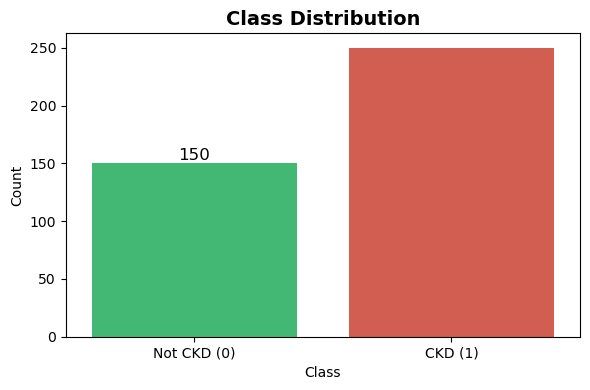

In [10]:
# Class Distribution Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='classification', data=df, palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Not CKD (0)', 'CKD (1)'])
ax.bar_label(ax.containers[0], fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

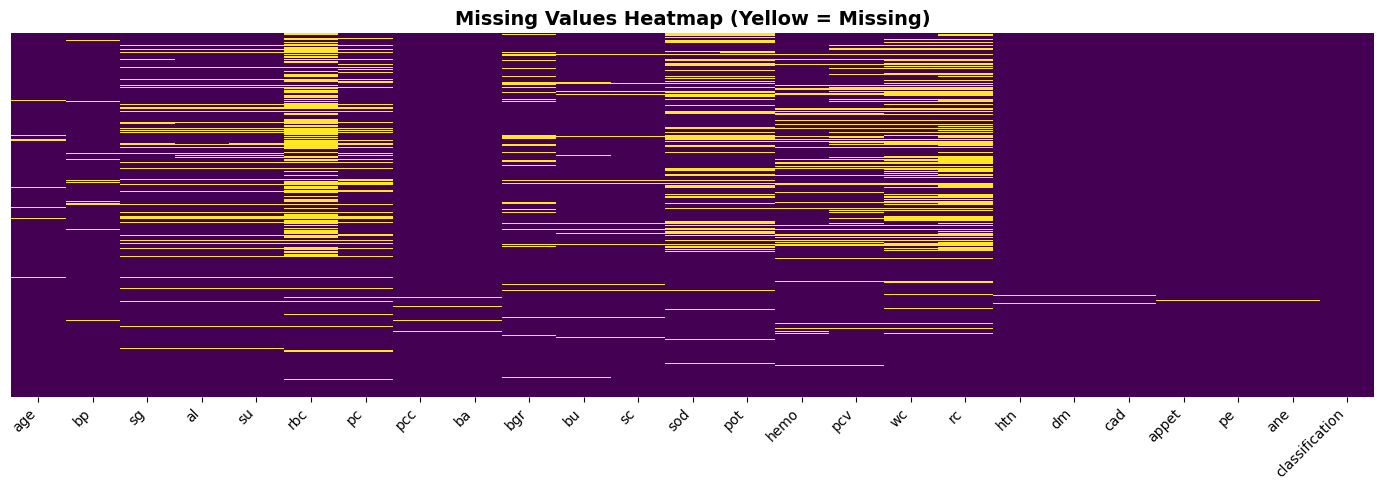

meaning: 
Yellow streaks = missing values. Columns like wc, rc, sod will show heavy missing streaks.


In [11]:
#Missing Values Heatmap
"""We need to reload the raw data just for this plot so we can show the original missing values (before imputation) in your report"""

df_raw = pd.read_csv('kidney_disease.csv')
df_raw.drop(columns=['id'], inplace=True)
df_raw['pcv'] = pd.to_numeric(df_raw['pcv'], errors='coerce')
df_raw['wc']  = pd.to_numeric(df_raw['wc'],  errors='coerce')
df_raw['rc']  = pd.to_numeric(df_raw['rc'],  errors='coerce')

plt.figure(figsize=(14, 5))
sns.heatmap(df_raw.isnull(), cbar=False, 
            cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

print(f"meaning: \n{"Yellow streaks = missing values. Columns like wc, rc, sod will show heavy missing streaks."}")

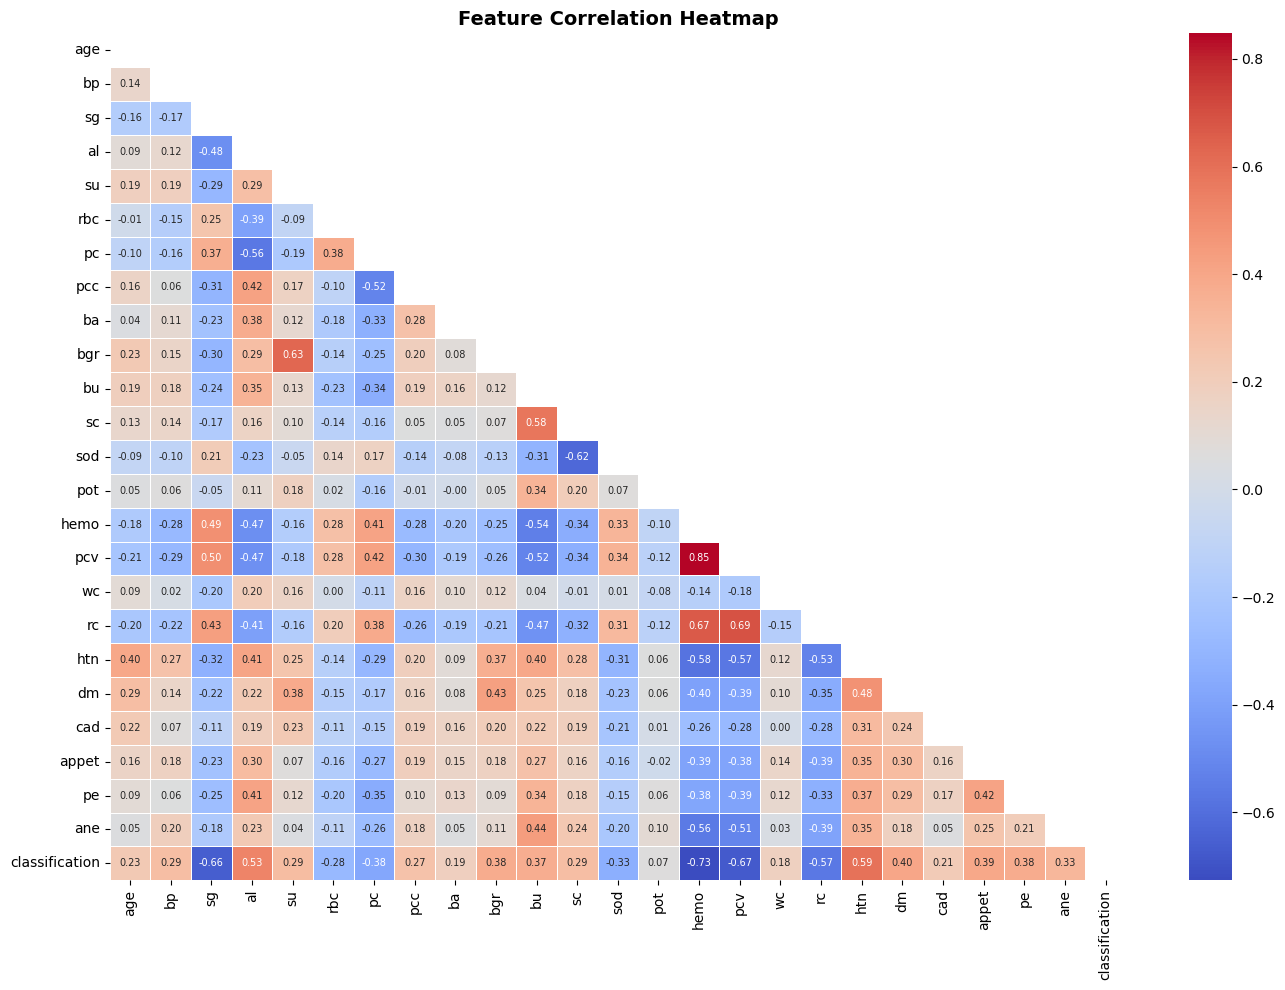

In [12]:
# Feature Correlation Heatmap
"""This shows how strongly each feature correlates with every other feature, including the target:"""

# Use df_raw but with numeric-only columns for correlation
df_corr = df.copy()

plt.figure(figsize=(14, 10))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

These plots show how the 6 most clinically important features differ between CKD and non-CKD patients:


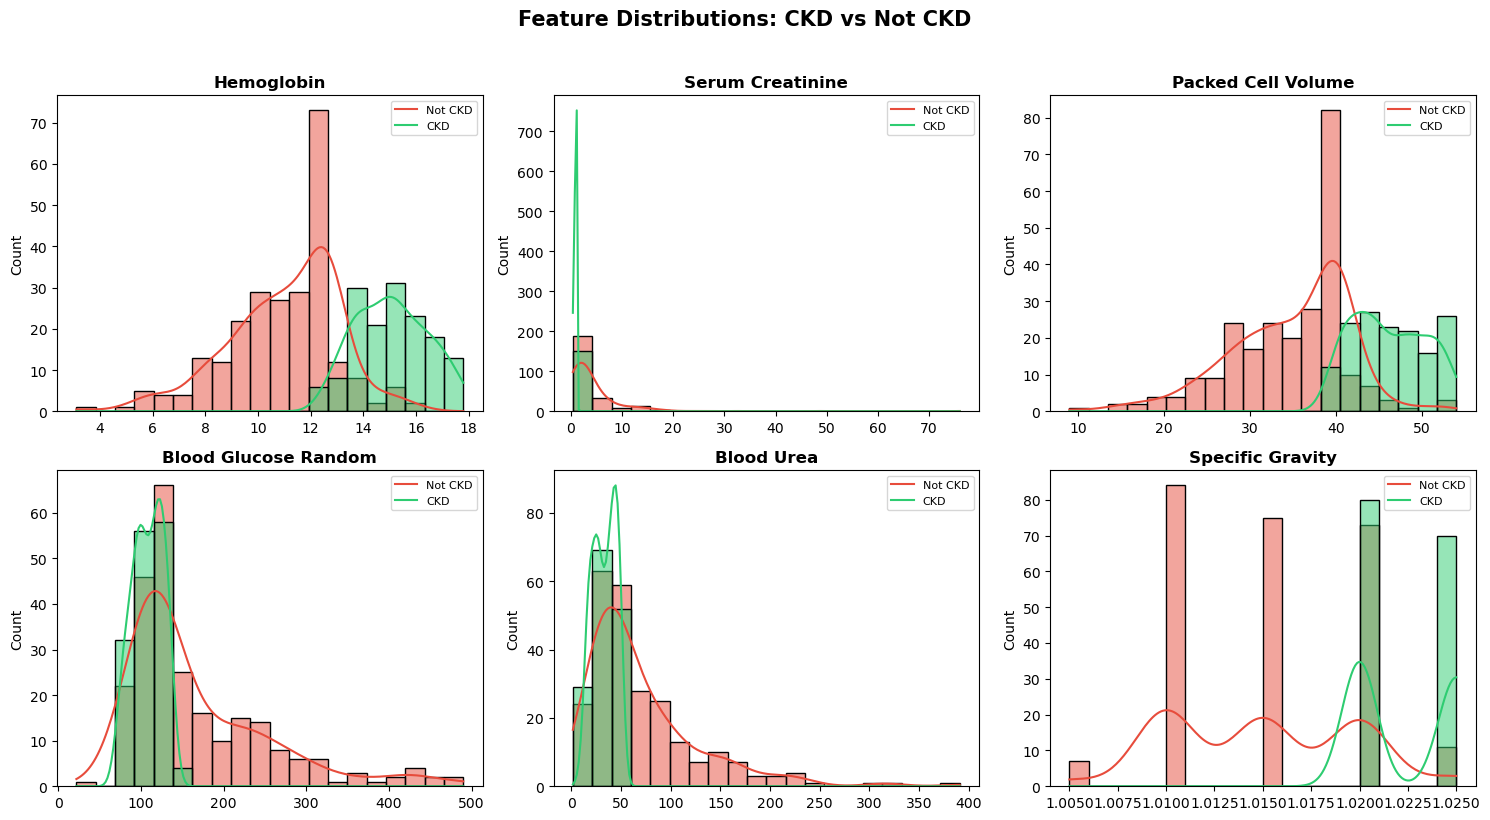

In [13]:
# Distribution Plots for Key Features
print ("These plots show how the 6 most clinically important features differ between CKD and non-CKD patients:")
key_features = ['hemo', 'sc', 'pcv', 'bgr', 'bu', 'sg']
titles = ['Hemoglobin', 'Serum Creatinine', 'Packed Cell Volume',
          'Blood Glucose Random', 'Blood Urea', 'Specific Gravity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (feat, title) in enumerate(zip(key_features, titles)):
    sns.histplot(data=df, x=feat, hue='classification',
                 kde=True, palette=['#2ecc71', '#e74c3c'],
                 ax=axes[i], bins=20)
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(labels=['Not CKD', 'CKD'], fontsize=8)

plt.suptitle('Feature Distributions: CKD vs Not CKD',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

# Model Building

In [14]:
# Define all 5 models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, 
                                                        learning_rate=0.1, 
                                                        random_state=42)
}

# Train all models and store them
trained_models = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)   # train on SMOTE-balanced data
    trained_models[name] = model         # save the trained model
    print(f"{name} trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
SVM trained successfully
Gradient Boosting trained successfully


# Model Evaluation

In [15]:
# Model Evaluation 

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability for ROC-AUC

    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob)
    })

# Display as a clean comparison table
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
results_df = results_df.round(4)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
      Random Forest    1.0000        1.0    1.00    1.0000     1.00
  Gradient Boosting    1.0000        1.0    1.00    1.0000     1.00
      Decision Tree    0.9875        1.0    0.98    0.9899     0.99
                SVM    0.9875        1.0    0.98    0.9899     1.00
Logistic Regression    0.9750        1.0    0.96    0.9796     1.00


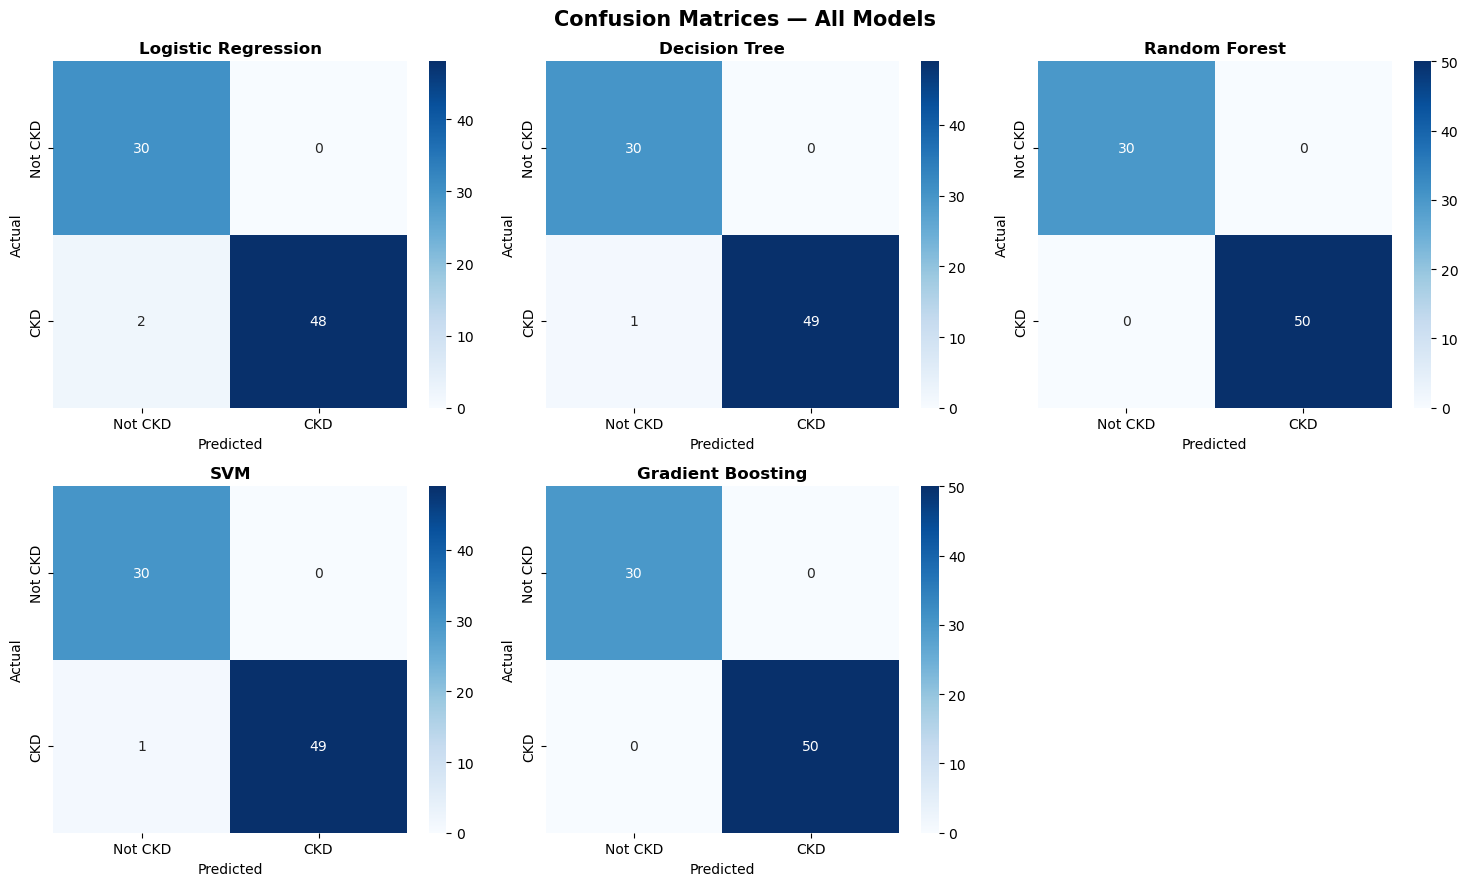

In [16]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not CKD', 'CKD'],
                yticklabels=['Not CKD', 'CKD'])
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].set_visible(False)  # hide the empty 6th subplot
plt.suptitle('Confusion Matrices — All Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

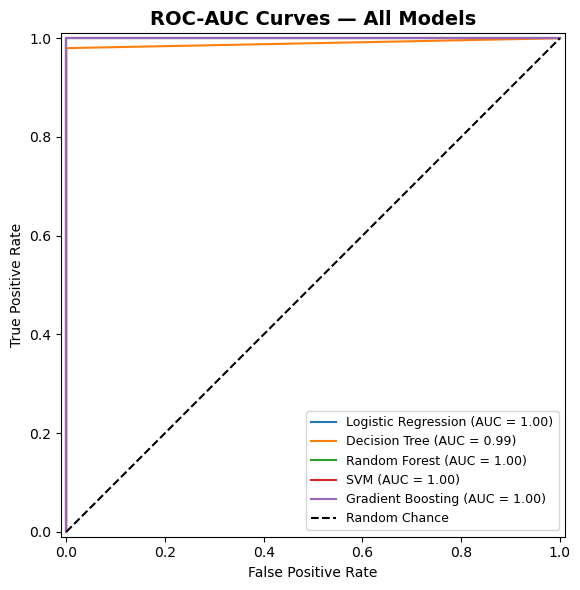

In [17]:
#  ROC-AUC Curves
plt.figure(figsize=(9, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob,
                                     name=name, ax=plt.gca())

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC-AUC Curves — All Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('roc_auc_curves.png', dpi=150)
plt.show()

In [19]:
# Cross-Validation Scores
print ("This tests how stable each model is across different subsets of the training data:")
print("5-Fold Cross-Validation Scores (on SMOTE training set):\n")

for name, model in trained_models.items():
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm,
                                cv=5, scoring='f1')
    print(f"{name:<25} Mean F1: {cv_scores.mean():.4f}  "
          f"Std: {cv_scores.std():.4f}")

This tests how stable each model is across different subsets of the training data:
5-Fold Cross-Validation Scores (on SMOTE training set):

Logistic Regression       Mean F1: 0.9924  Std: 0.0062
Decision Tree             Mean F1: 0.9824  Std: 0.0129
Random Forest             Mean F1: 0.9925  Std: 0.0100
SVM                       Mean F1: 0.9923  Std: 0.0102
Gradient Boosting         Mean F1: 0.9925  Std: 0.0062


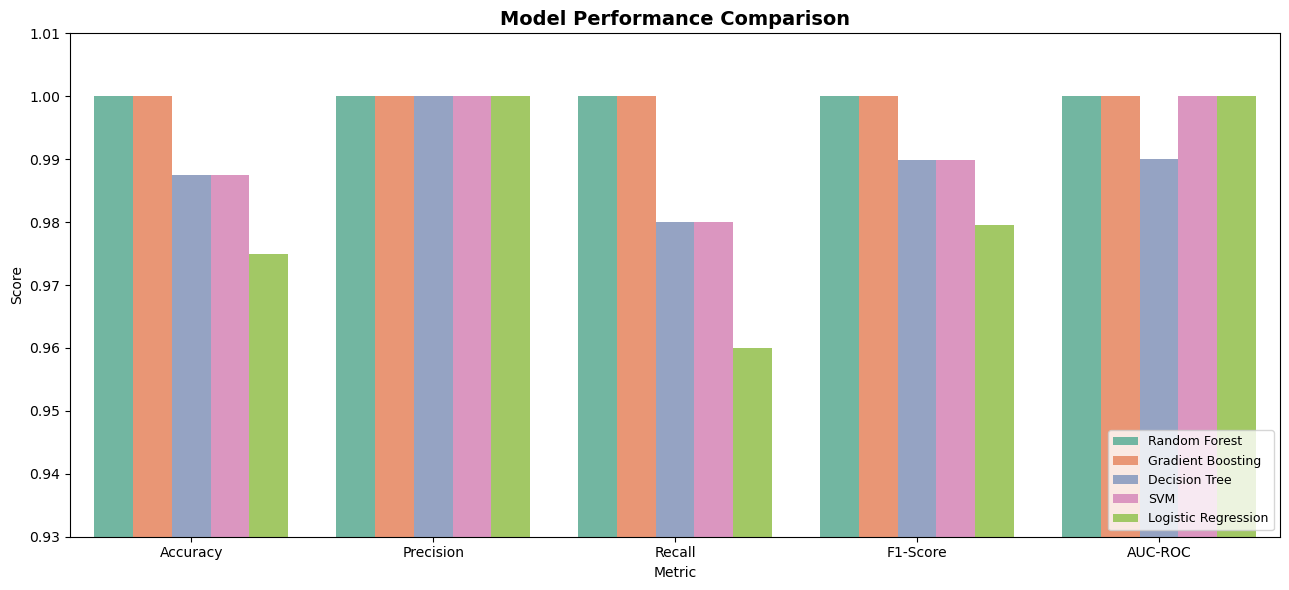


Best Model: Random Forest


In [21]:
# Visual Comparison Table

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

results_melted = results_df.melt(id_vars='Model', 
                                  value_vars=metrics,
                                  var_name='Metric', 
                                  value_name='Score')

plt.figure(figsize=(13, 6))
sns.barplot(data=results_melted, x='Metric', y='Score', 
            hue='Model', palette='Set2')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim(0.93, 1.01)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# Also print the best model
best_model_name = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")

Since both Random Forest and Gradient Boosting scored 1.0, we'll pick Random Forest as our best model for SHAP analysis and deployment because:

- It's faster to run SHAP on
- It's easier to interpret
- It's more widely used in clinical ML research

# Best Model — Explicit Test Set Evaluation

   RANDOM FOREST — TEST SET EVALUATION
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

AUC-ROC Score : 1.0000


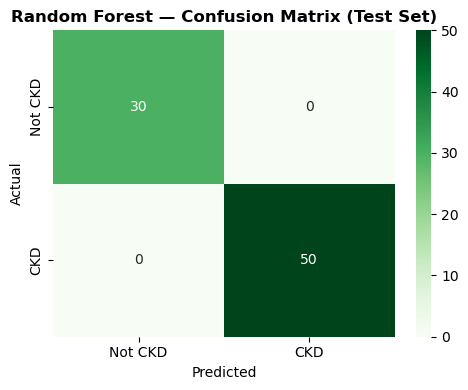

In [22]:
# Select best model
best_model = trained_models['Random Forest']

# Predict on test set
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Full classification report
print("=" * 50)
print("   RANDOM FOREST — TEST SET EVALUATION")
print("=" * 50)
print(classification_report(y_test, y_pred_best, 
                             target_names=['Not CKD', 'CKD']))
print(f"AUC-ROC Score : {roc_auc_score(y_test, y_prob_best):.4f}")

# Confusion matrix for best model alone
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not CKD', 'CKD'],
            yticklabels=['Not CKD', 'CKD'])
plt.title('Random Forest — Confusion Matrix (Test Set)', 
          fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=150)
plt.show()

# SHAP Explainability.

In [23]:
# Create SHAP explainer using the best model (Random Forest)
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on the test set
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list of 2 arrays
# Index [1] = SHAP values for the positive class (CKD)
print("SHAP values shape:", shap_values[1].shape)  # should be (80, 24)

SHAP values shape: (24, 2)


In [25]:
#  Fix: extract correct SHAP values 
# New SHAP versions return shape (n_samples, n_features, n_classes)
# We want class 1 (CKD) → last index [:, :, 1]

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]          # shape → (80, 24)
    base_val = explainer.expected_value[1]
elif isinstance(shap_values, list):
    sv = shap_values[1]                # old SHAP format
    base_val = explainer.expected_value[1]
else:
    sv = shap_values
    base_val = explainer.expected_value

print("Corrected SHAP values shape:", sv.shape)  # should be (80, 24)

Corrected SHAP values shape: (80, 24)


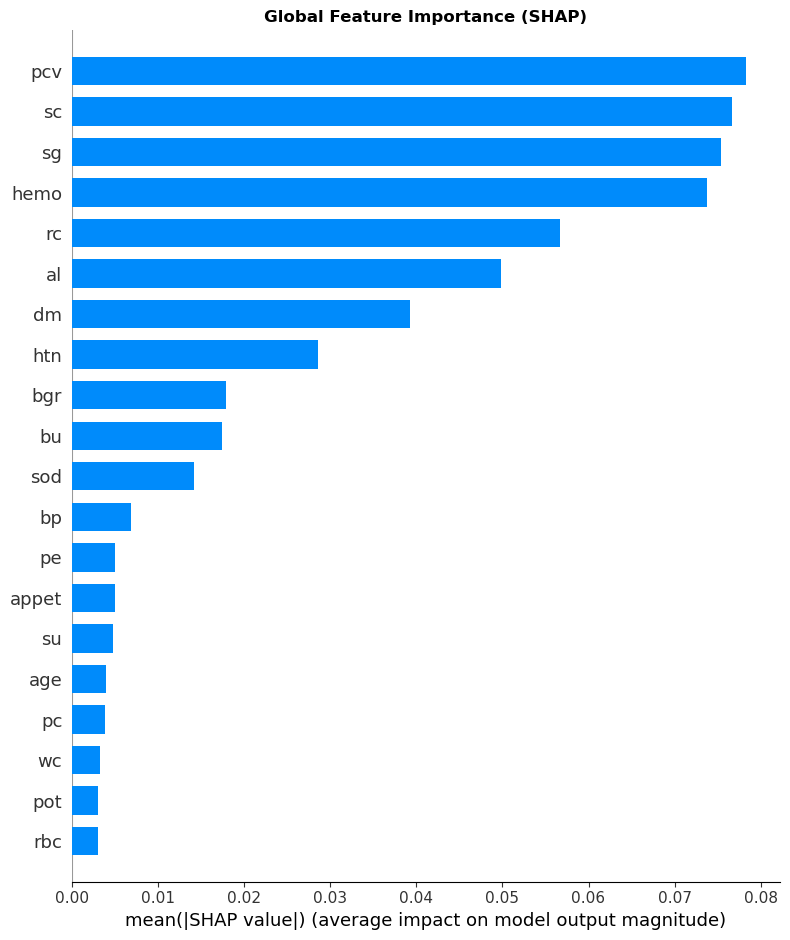

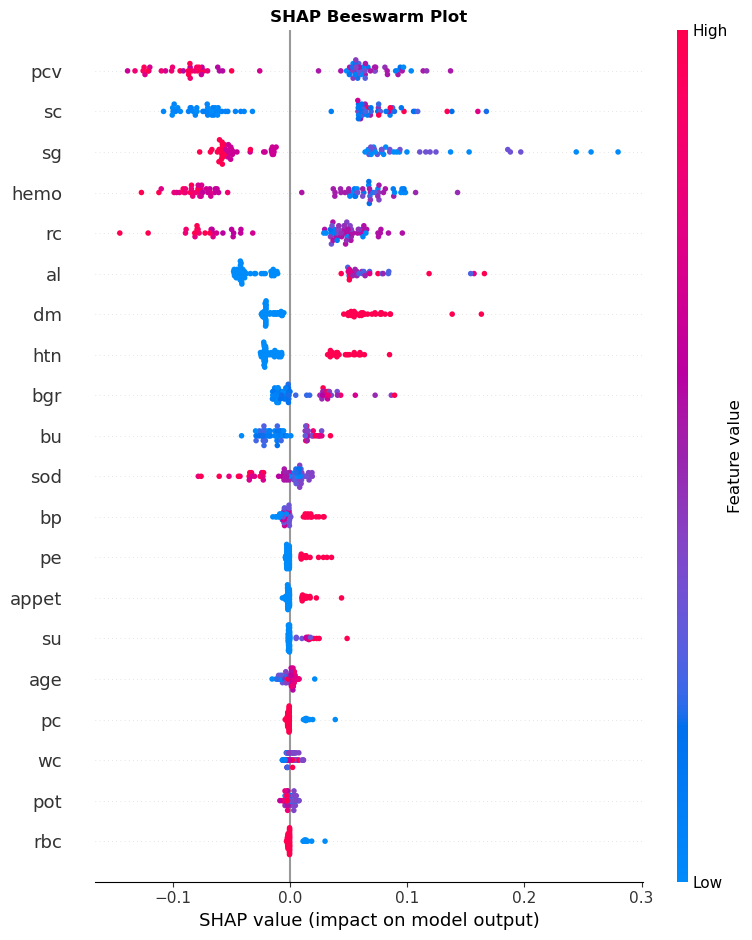

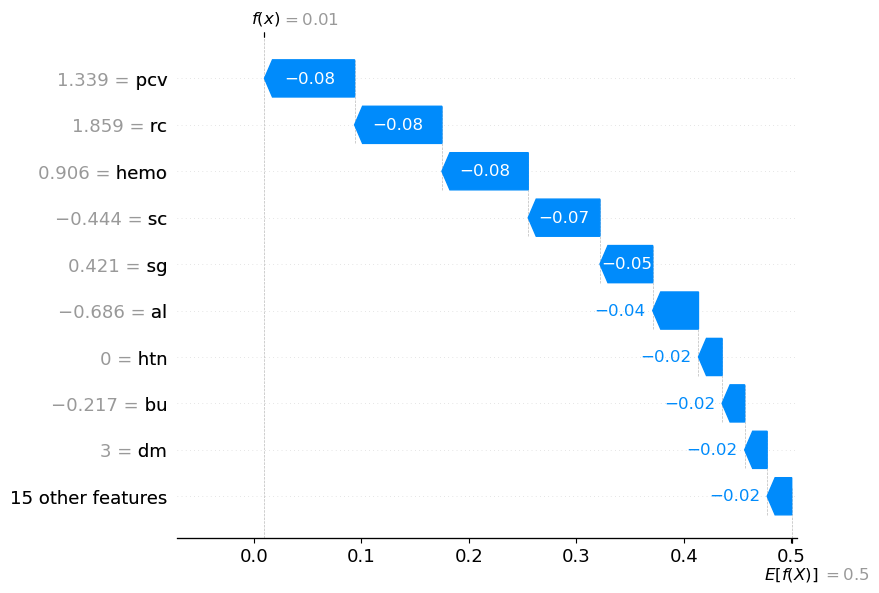

<Figure size 640x480 with 0 Axes>


Patient 0 — Predicted: Not CKD
Probability of CKD   : 0.0100


In [26]:
# Bar Plot
plt.figure()
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 6.3 — Beeswarm Plot
plt.figure()
shap.summary_plot(sv, X_test, show=False)
plt.title('SHAP Beeswarm Plot', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 6.4 — Waterfall Plot (Patient 0)
shap.plots.waterfall(
    shap.Explanation(
        values        = sv[0],
        base_values   = base_val,
        data          = X_test.iloc[0],
        feature_names = X_test.columns.tolist()
    )
)
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

pred = best_model.predict(X_test.iloc[[0]])[0]
prob = best_model.predict_proba(X_test.iloc[[0]])[0][1]
print(f"\nPatient 0 — Predicted: {'CKD' if pred == 1 else 'Not CKD'}")
print(f"Probability of CKD   : {prob:.4f}")

# Save the Model + Streamlit Deployment

In [27]:
#  Phase 7: Save Model 

import joblib

# Save the trained Random Forest model
joblib.dump(best_model, 'ckd_model.pkl')

# Save the scaler (we need this to scale new patient input in the app)
joblib.dump(scaler, 'ckd_scaler.pkl')

print("Model saved as: ckd_model.pkl")
print("Scaler saved as: ckd_scaler.pkl")

Model saved as: ckd_model.pkl
Scaler saved as: ckd_scaler.pkl


In [28]:
# Check the exact column order the model was trained on
print(X_train_sm.columns.tolist())

['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
